Maybe try to read in the opera datasets into MintPy for improved time series velocities and ascending/descending decomposition? Then clip the datasets by the aquifers for zonal statistics?

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from mintpy import view, tsview
import os
from pathlib import Path
import geopandas as gpd
from transboundary_opera.decomposer import InSARDecomposer
import transboundary_opera.decomposition_tools as dt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
gdf = gpd.read_file(Path(os.getcwd()).parent.parent / "raw_data/TBA_full.shp")


data_storage = Path('/home/clayc/Documents/US_Mex_InSAR') / "OPERA_data"    # linux
# data_storage = Path('/mnt/c/Users/clayc/Documents/US_Mex_InSAR') / "OPERA_data"    # WSL
mintpy_paths = list(data_storage.glob('*/mintpy'))
opera_product_paths = list(data_storage.glob('*/subset-ncs/*.nc'))

In [4]:
# overlapping_pairs = get_asc_desc_pairs(data_storage)

overlapping_pairs = dt.get_asc_desc_pairs(data_storage)
print(len(overlapping_pairs))

Caching valid data masks and dates...
21


## Process all identified pairs

In [ ]:
processor = InSARDecomposer(overlapping_pairs, ds_name='timeseries', angle=-90)
processor.run()
print(processor.successful_pairs)
print(processor.failed_pairs)

Processing pair 1/21
  Using 8 common dates out of 8 and 18
  Failed: input dataset ['azimuthAngle'] not found in file /home/clayc/Documents/US_Mex_InSAR/OPERA_data/26691/mintpy/geometryGeo.h5
Processing pair 2/21
  Using 9 common dates out of 12 and 11
  Failed: input dataset ['azimuthAngle'] not found in file /home/clayc/Documents/US_Mex_InSAR/OPERA_data/3065/mintpy/geometryGeo.h5
Processing pair 3/21
  Using 11 common dates out of 17 and 11
  Decomposing 11 time slices...
decomposing asc/desc into horz/vert direction in windows of 20x20 ...
[==================================================] 269/269   16s /     0s 
decomposing asc/desc into horz/vert direction in windows of 20x20 ...
[==================================================] 269/269   16s /     0s 
decomposing asc/desc into horz/vert direction in windows of 20x20 ...
[==================================================] 269/269   16s /     0s 
decomposing asc/desc into horz/vert direction in windows of 20x20 ...
[========

/home/clayc/git_repos/Transboundary_Opera/src/transboundary_opera/decomposer.py:247: RuntimeWarning: Mean of empty slice
  mean_coh = np.nanmean(data['coh'], axis=0)


  Writing horizontal: /home/clayc/Documents/US_Mex_InSAR/OPERA_data/40297_42264_dhorz.h5
delete exsited file: /home/clayc/Documents/US_Mex_InSAR/OPERA_data/40297_42264_dhorz.h5
create HDF5 file: /home/clayc/Documents/US_Mex_InSAR/OPERA_data/40297_42264_dhorz.h5 with w mode
create dataset /timeseries of float32    in size of (11, 5365, 5872)     with compression=None
create dataset /date       of |S8        in size of (11,)                with compression=None
finished writing to /home/clayc/Documents/US_Mex_InSAR/OPERA_data/40297_42264_dhorz.h5
  Writing vertical:   /home/clayc/Documents/US_Mex_InSAR/OPERA_data/40297_42264_dvert.h5
delete exsited file: /home/clayc/Documents/US_Mex_InSAR/OPERA_data/40297_42264_dvert.h5
create HDF5 file: /home/clayc/Documents/US_Mex_InSAR/OPERA_data/40297_42264_dvert.h5 with w mode
create dataset /timeseries of float32    in size of (11, 5365, 5872)     with compression=None
create dataset /date       of |S8        in size of (11,)                with co

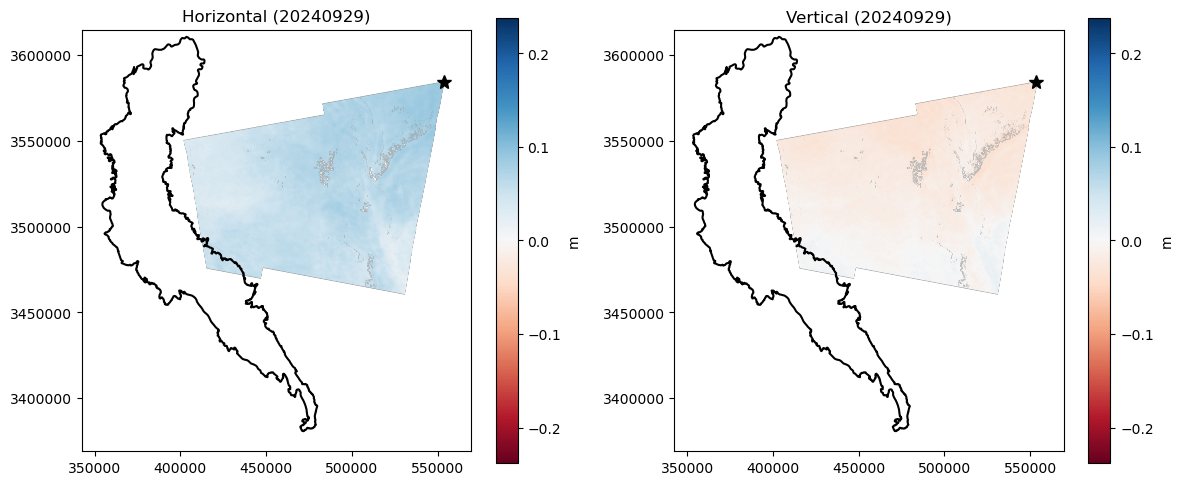

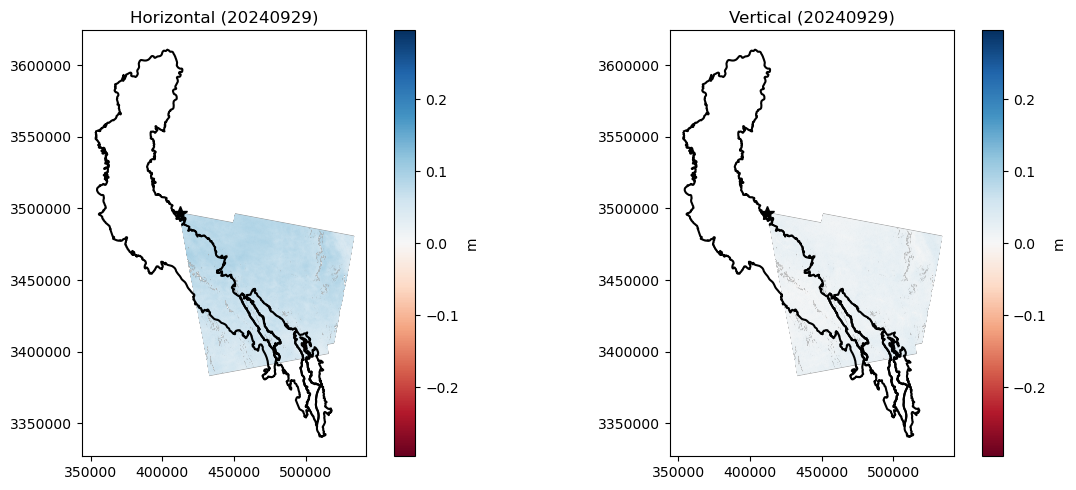

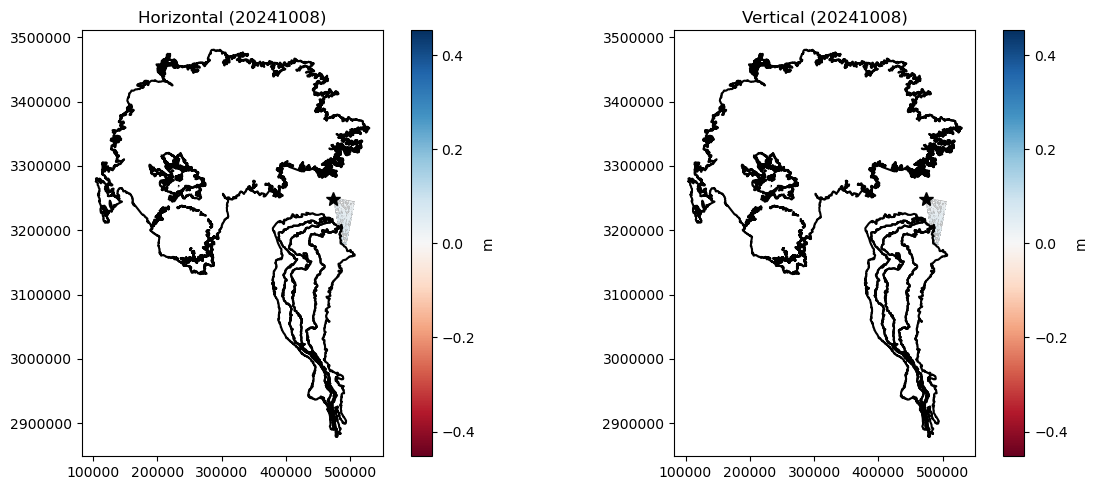

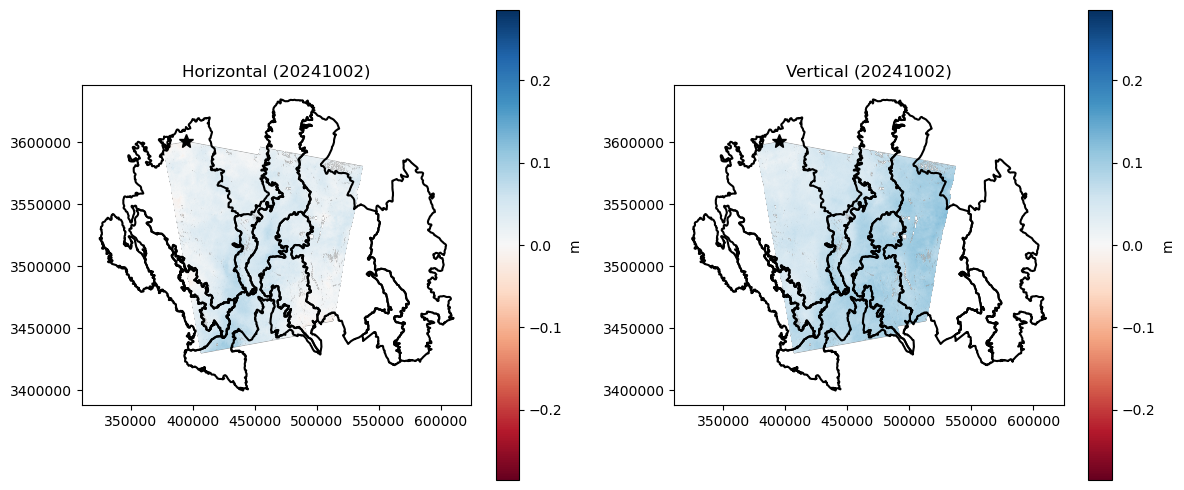

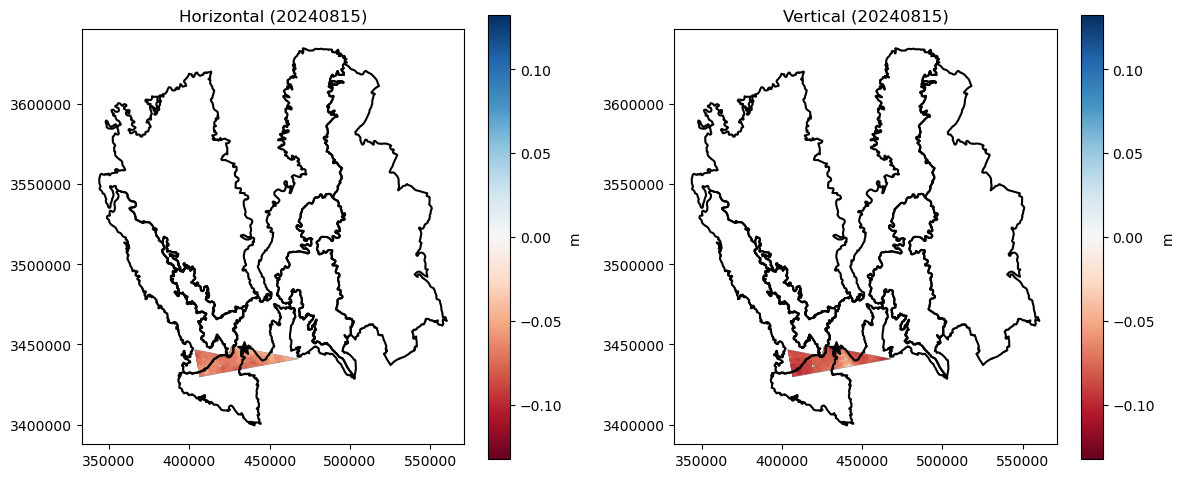

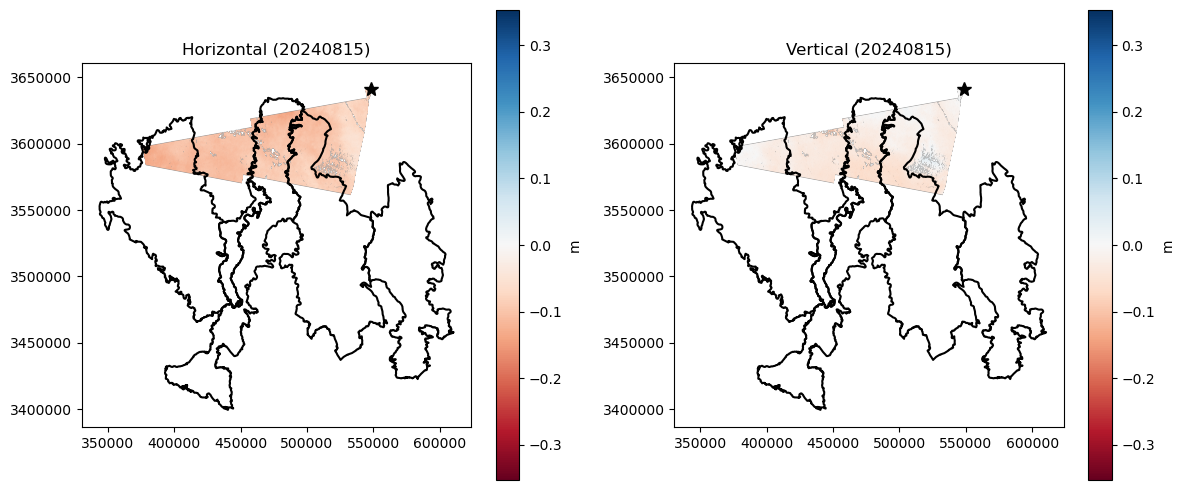

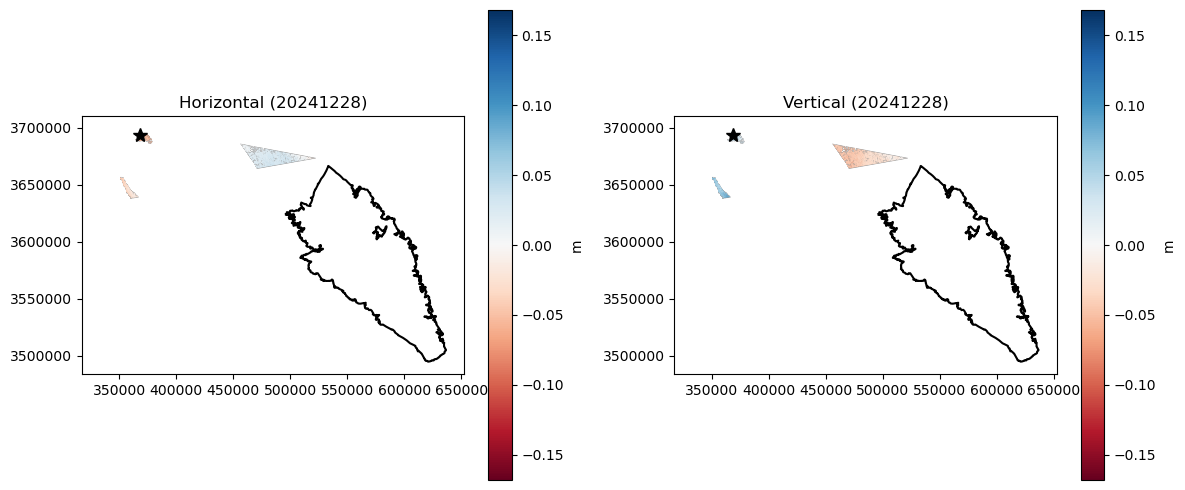

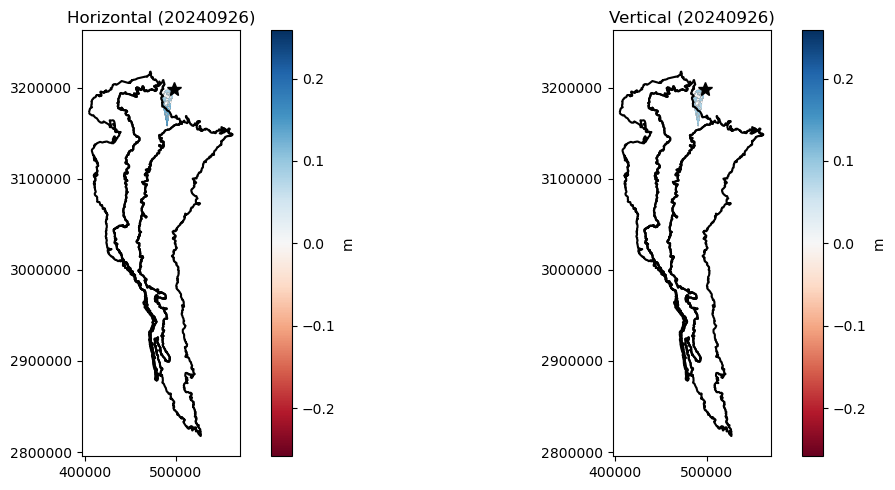

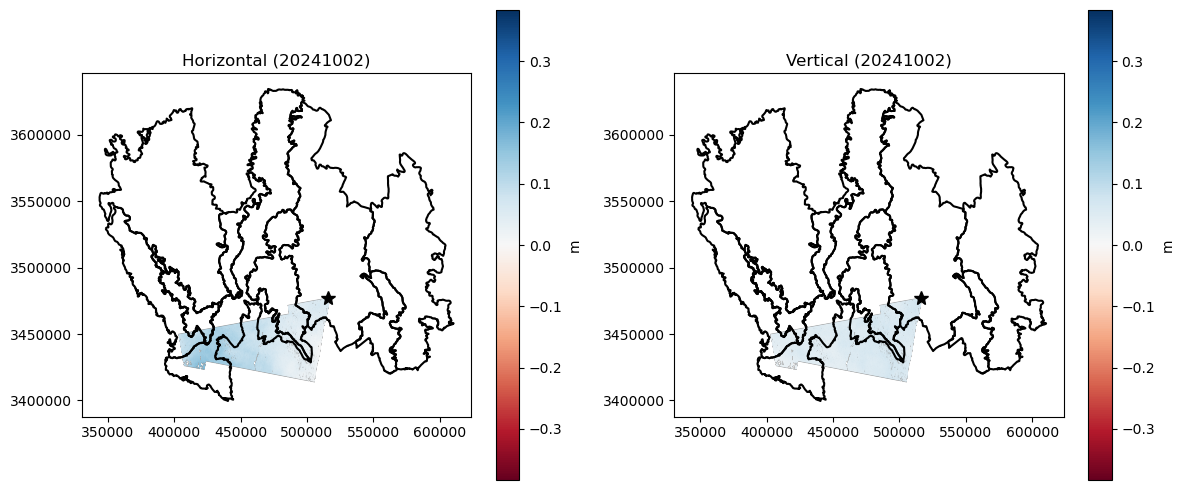

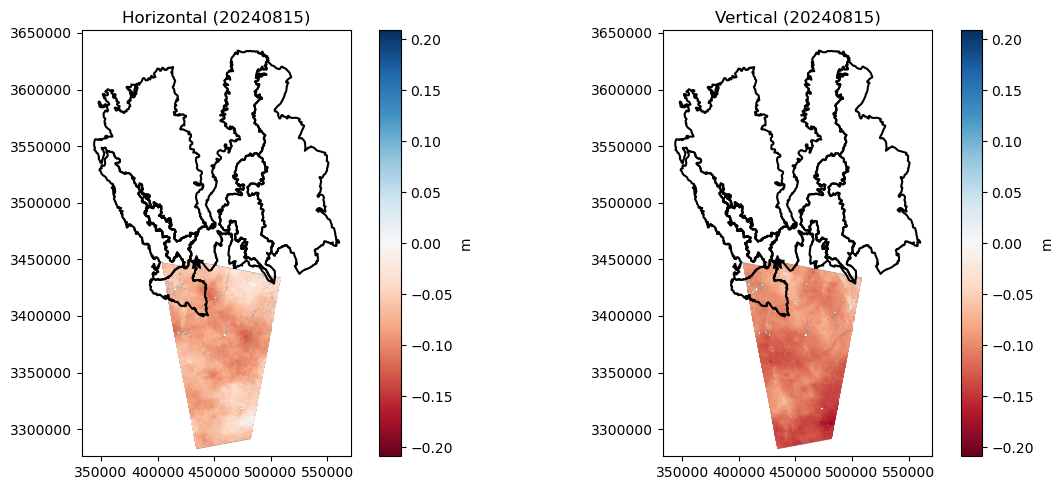

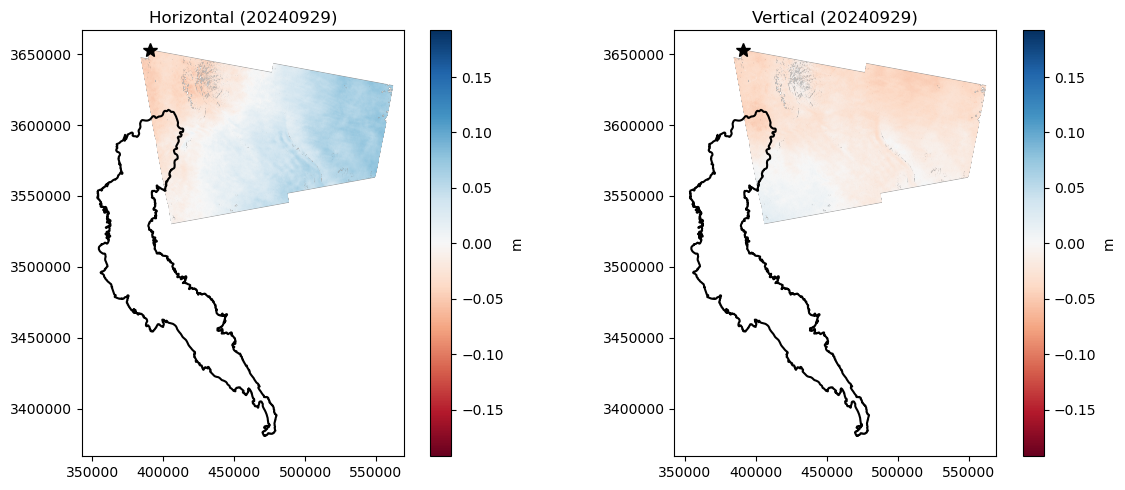

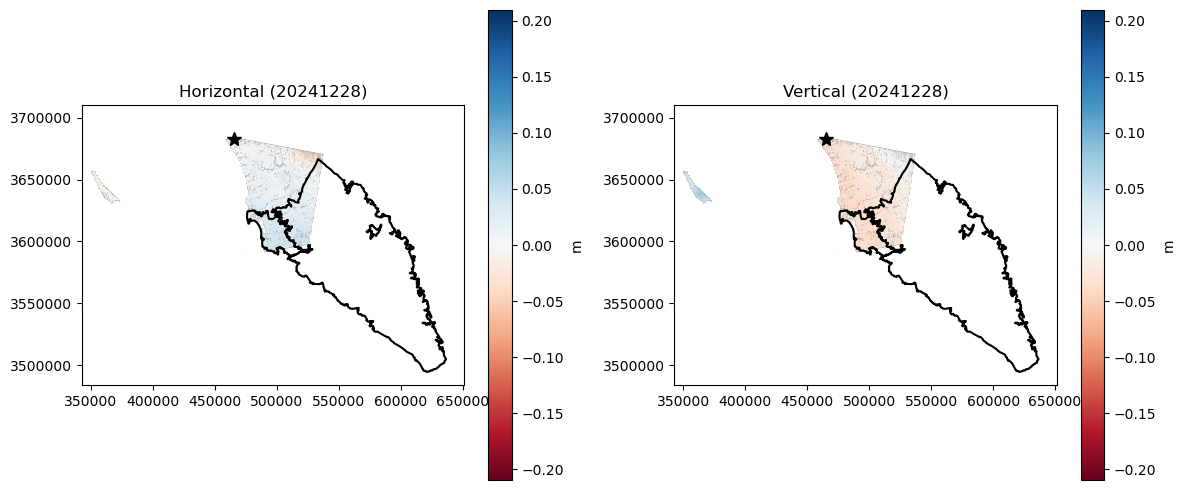

/home/clayc/git_repos/Transboundary_Opera/src/transboundary_opera/decomposition_tools.py:220: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  gdf_plot.boundary.plot(ax=ax, color=boundary_color, linewidth=boundary_linewidth)


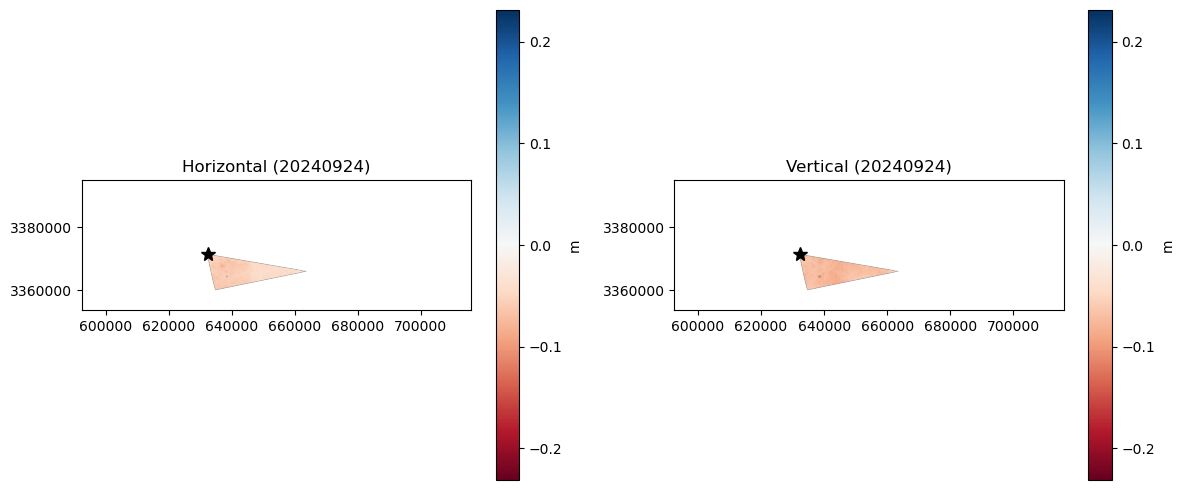

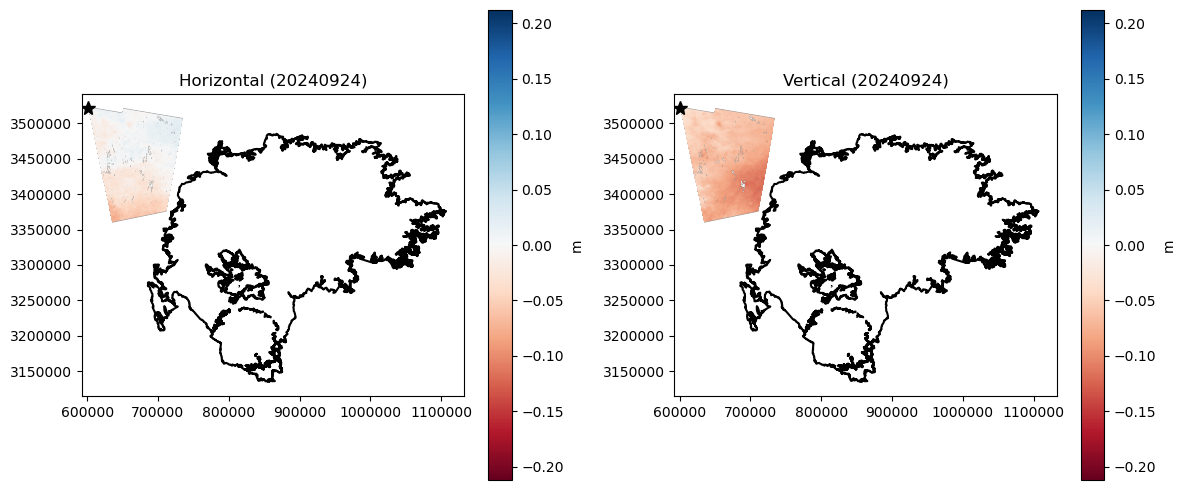

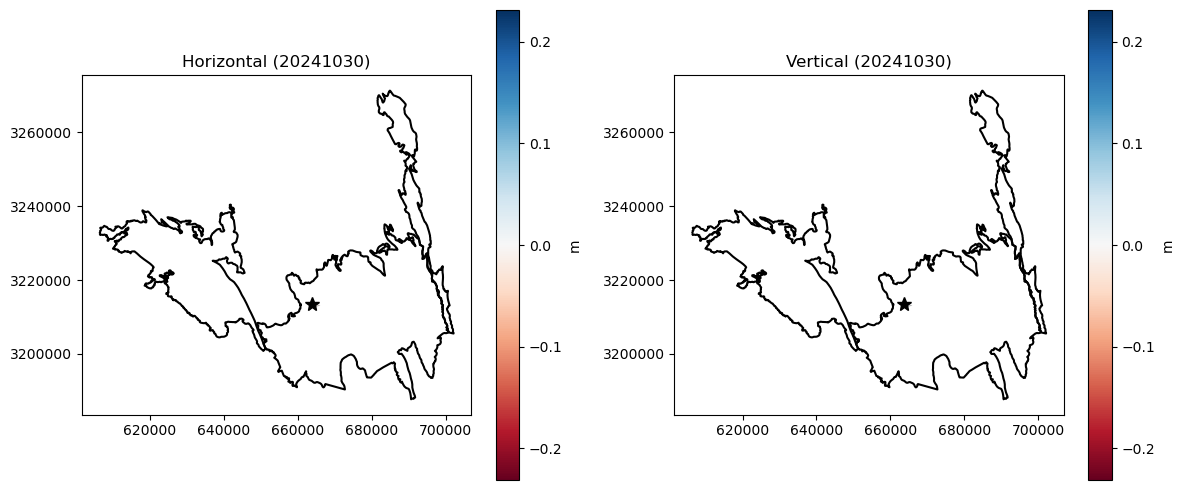

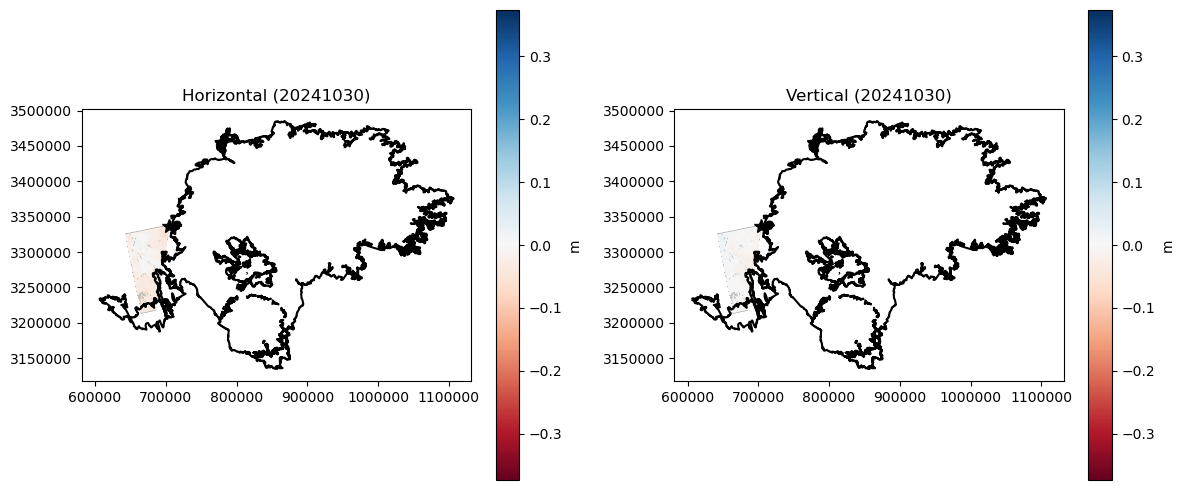

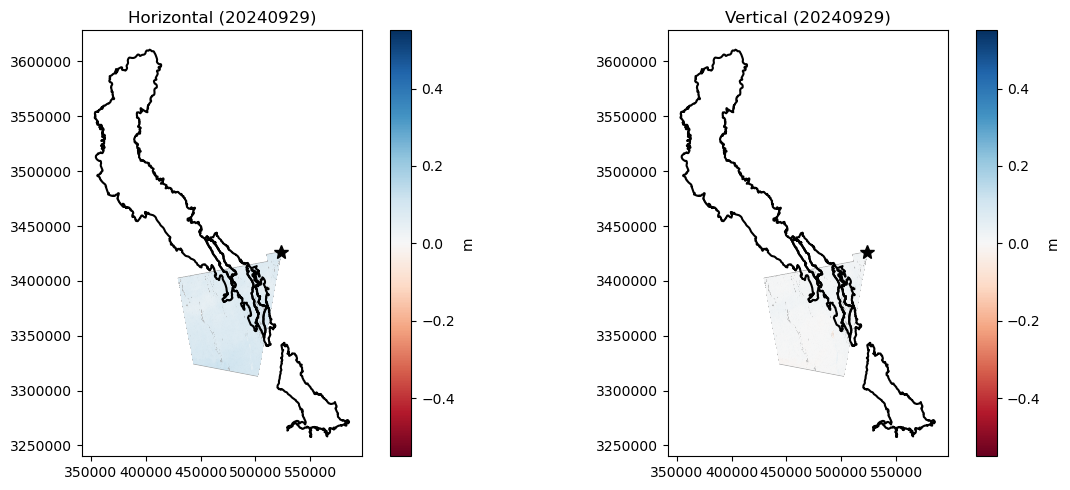

In [ ]:
# TODO: Make sure that we have downloaded all of the data covering the aquifers, spatially
# TODO: Exapnd the number of days we are searching

for pair in processor.successful_pairs:
    fig = dt.plot_displacements(pair['horz'], pair['vert'], time_idx=-1, gdf=gdf)

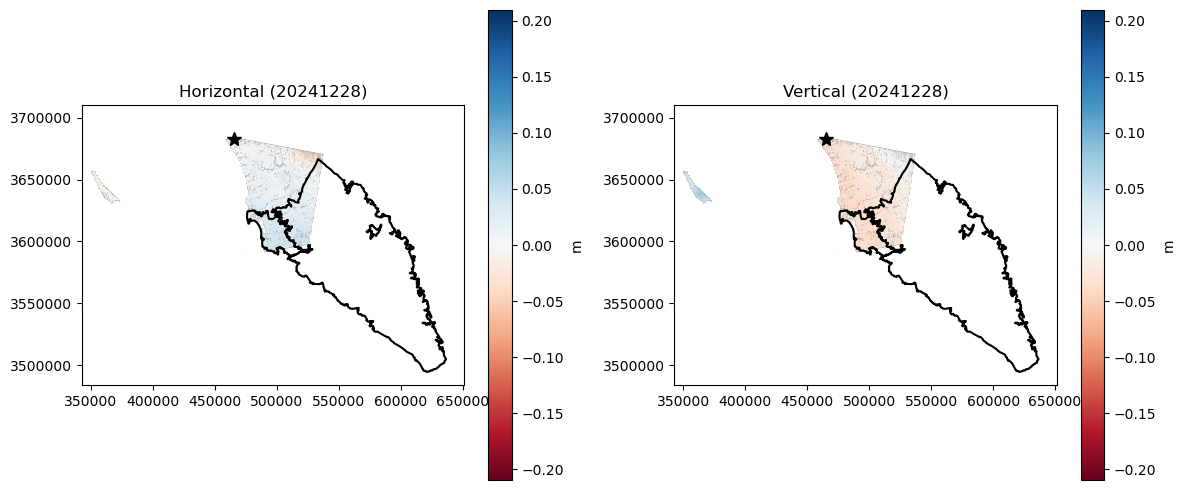

In [9]:
# examine outputs to check
test_files = ['/home/clayc/Documents/US_Mex_InSAR/OPERA_data/16939_18905_dhorz.h5', '/home/clayc/Documents/US_Mex_InSAR/OPERA_data/16939_18905_dvert.h5']
fig = dt.plot_displacements(test_files[0], test_files[1], time_idx=-1, gdf=gdf)

## Process individual pairs and visualize them alongside intersecting aquifer boundaries

In [ ]:
pair = overlapping_pairs[2]
processor = InSARDecomposer(pair, ds_name='timeseries', azimuth=-90)

outfiles = InSARDecomposer.process_pair(processor, pair=pair)
fig = dt.plot_displacements(outfiles['horz'], outfiles['vert'], time_idx=0, gdf=gdf)